In [2]:
%pip install yfinance
%pip install matplotlib
%pip install sqlite as sq3
%pip install numpy
%pip install pandas

##Install the packages and libraries used in this module

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement sqlite (from versions: none)
ERROR: No matching distribution found for sqlite
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import datetime
from numpy import random
import seaborn as sns
##Import pandas, yfinance, numpy and matplotlib from the downloaded libraries

In [ ]:
hyundai=pd.read_csv('Hyundai_Stocks.csv',skiprows=1) #Ignore the first row
#From the downloaded excel csv file with history of Hyundai Stocks, simply import it and use pandas to read is

In [44]:
import os

print("Current folder:", os.getcwd())
print("Files:", os.listdir())

Current folder: /Users/jake.l/Desktop/python-test/Analysis
Files: ['Hyundai_Dataset.numbers', 'Sales_Analysis.ipynb', 'Jake_Lee_Resume_Lifespace_Group.pdf', 'Hyundai_Analysis.ipynb', 'Walmart_Dataset.numbers', 'Hyundai Motor Stock Price History (1).xlsx', 'Walmart_Dataset.csv', 'Hyundai Motor Stock Price History .csv', 'Hyundai_Stocks.numbers', 'Hyundai_Stocks.csv', 'Numpy.py', 'Numpy_Rev', 'Hyundai_Analysis_Images.docx', 'Hyundai_DCF_Analysis.xlsx', 'Numpy_TUT.ipynb', 'Hyundai_Analysis_Images.pdf', 'Hyundai_Share_Prices.csv']


In [45]:
hyundai

,Hyundai Motor Stock Price History (1),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Date,Price,Open,High,Low,Vol.,Change %
1,8/25/2026,"421,000","422,000","427,250","406,000",570.22K,1.69%
2,8/24/2026,"414,000","416,000","420,000","408,000",349.74K,-0.24%
3,8/21/2026,"415,000","406,500","420,500","405,000",371.71K,-0.60%
4,8/20/2026,"417,500","417,000","425,000","408,000",421.24K,0.85%
...,...,...,...,...,...,...,...
2088,2/1/2019,"129,500","129,500","130,000","128,500",391.59K,0.00%
2089,1/31/2019,"129,500","130,000","131,000","128,500",509.45K,0.00%
2090,1/30/2019,"129,500","128,500","129,500","126,500",404.00K,1.17%
2091,1/29/2019,"128,000","126,500","128,500","126,000",445.08K,1.19%


In [46]:
hyundai.columns=hyundai.iloc[0]
#Removes any unnecessary column headers

In [47]:
hyundai2=hyundai.iloc[1:]
hyundai2['Date'] = pd.to_datetime(hyundai2['Date'])

hyundai_data = hyundai2.set_index('Date')

In [48]:
hyundai2.dtypes

0
Date        datetime64[us]
Price                  str
Open                   str
High                   str
Low                    str
Vol.                   str
Change %               str
dtype: object

In [49]:
hyundai_data=hyundai2.set_index('Date')
#Set the index to Date


In [50]:
hyundai_data=hyundai_data.rename(columns={'Price':'Price_KRWon'}) 
#Change the column name from Price --> Price_KRWon for clarity

In [51]:
hyundai_data.dtypes
#Currently, the datas are set all in objects

0
Price_KRWon    str
Open           str
High           str
Low            str
Vol.           str
Change %       str
dtype: object

In [52]:
hyundai_data['Price_KRWon'].convert_dtypes(float)

Date
2026-08-25    421,000
2026-08-24    414,000
2026-08-21    415,000
2026-08-20    417,500
2026-08-19    414,000
               ...   
2019-02-01    129,500
2019-01-31    129,500
2019-01-30    129,500
2019-01-29    128,000
2019-01-28    126,500
Name: Price_KRWon, Length: 2092, dtype: string

In [53]:
hyundai_data['Price_KRWon']
hyundai_data.dtypes

0
Price_KRWon    str
Open           str
High           str
Low            str
Vol.           str
Change %       str
dtype: object

In [54]:
hyundai_datas=hyundai_data.copy()

In [55]:
hyundai_datas=hyundai_datas.replace(',','',regex=True) #Finds a pattern of ',' and replaces it with ''. This is done so that when converting into float64, the commas don't interfere with the conversion

In [56]:
hyundai_datas['Change %']=hyundai_datas['Change %'].replace('%','',regex=True) #Finds a pattern of '%' and replaces it with ''. This is done so that when converting into float64, the % don't interfere with the conversion

In [57]:
hdata=hyundai_datas.iloc[:,[0,1,2,3,5]] #Exclude Volume column cause it is irrelevant

In [58]:
hdata=hdata.astype(float)
hdata.dtypes

0
Price_KRWon    float64
Open           float64
High           float64
Low            float64
Change %       float64
dtype: object

In [59]:
hdata
hdata['Price_AUD']=hdata['Price_KRWon']/990.03 #Exchange Rate from KR Won to AUD. Exchange Rate has been taken from https://www.rba.gov.au/statistics/frequency/exchange-rates.html, RBA, used 28/08/2026 exchange rates. (Potentially change so exchange rates are updated live?)

In [60]:
hdata

,Price_KRWon,Open,High,Low,Change %,Price_AUD
Date,,,,,,
2026-08-25,421000.0,422000.0,427250.0,406000.0,1.69,425.239639
2026-08-24,414000.0,416000.0,420000.0,408000.0,-0.24,418.169146
2026-08-21,415000.0,406500.0,420500.0,405000.0,-0.60,419.179217
2026-08-20,417500.0,417000.0,425000.0,408000.0,0.85,421.704393
2026-08-19,414000.0,416000.0,422500.0,406500.0,-4.83,418.169146
...,...,...,...,...,...,...
2019-02-01,129500.0,129500.0,130000.0,128500.0,0.00,130.804117
2019-01-31,129500.0,130000.0,131000.0,128500.0,0.00,130.804117
2019-01-30,129500.0,128500.0,129500.0,126500.0,1.17,130.804117


In [61]:
hprice=hdata.Price_AUD #Now, we will be using this AUD Prices to commence the Monte-Carlo Simulation
hprice

Date
2026-08-25    425.239639
2026-08-24    418.169146
2026-08-21    419.179217
2026-08-20    421.704393
2026-08-19    418.169146
                 ...    
2019-02-01    130.804117
2019-01-31    130.804117
2019-01-30    130.804117
2019-01-29    129.289011
2019-01-28    127.773906
Name: Price_AUD, Length: 2092, dtype: float64

In [62]:
hprices=hprice.pct_change()
hprices

Date
2026-08-25         NaN
2026-08-24   -0.016627
2026-08-21    0.002415
2026-08-20    0.006024
2026-08-19   -0.008383
                ...   
2019-02-01    0.027778
2019-01-31    0.000000
2019-01-30    0.000000
2019-01-29   -0.011583
2019-01-28   -0.011719
Name: Price_AUD, Length: 2092, dtype: float64

In [63]:
AUD_Hyundai=pd.DataFrame([hprice,hprices]).T #Compute the %Changes as well
AUD_Hyundai.rename(columns={4: '%_Change'})

,Price_AUD,Price_AUD
Date,,
2026-08-25,425.239639,NaN
2026-08-24,418.169146,-0.016627
2026-08-21,419.179217,0.002415
2026-08-20,421.704393,0.006024
2026-08-19,418.169146,-0.008383
...,...,...
2019-02-01,130.804117,0.027778
2019-01-31,130.804117,0.000000
2019-01-30,130.804117,0.000000


In [64]:
AUD_Hyundai.columns=['Price_AUD','Percent_AUD']

In [65]:
AUD_Hyundai.dropna(inplace=True)

In [66]:
AUD_Hyundai['Cumfactor']=AUD_Hyundai.Percent_AUD+1


In [67]:
AUD_Hyundai=AUD_Hyundai.reset_index()

In [68]:
AUD_Hyundai['Date']=pd.to_datetime(AUD_Hyundai['Date'])

In [69]:
AUD_Hyundai.set_index('Date')

,Price_AUD,Percent_AUD,Cumfactor
Date,,,
2026-08-24,418.169146,-0.016627,0.983373
2026-08-21,419.179217,0.002415,1.002415
2026-08-20,421.704393,0.006024,1.006024
2026-08-19,418.169146,-0.008383,0.991617
2026-08-18,439.380625,0.050725,1.050725
...,...,...,...
2019-02-01,130.804117,0.027778,1.027778
2019-01-31,130.804117,0.000000,1.000000
2019-01-30,130.804117,0.000000,1.000000


In [70]:
#AUD_Hyundai=AUD_Hyundai.set_index('Date') #Date was set in Object DataType so convert it into DateTime to sort it accordingly
AUD_Hyundai['Date'].sort_index(ascending=True)
AUD_Hyundai['Logarithmic_Changes_Daily']=np.log((AUD_Hyundai.Price_AUD/AUD_Hyundai['Price_AUD'].shift(1))) #Logarithmic changes can be estimated roughly up to +-5% changes. https://people.duke.edu/~rnau/411log.htm
AUD_Hyundai=AUD_Hyundai.sort_index(ascending=False)
simulation=AUD_Hyundai.copy()
simulation.dropna(inplace=True)
simulation=simulation.set_index('Date')
simulation

,Price_AUD,Percent_AUD,Cumfactor,Logarithmic_Changes_Daily
Date,,,,
2019-01-28,127.773906,-0.011719,0.988281,-0.011788
2019-01-29,129.289011,-0.011583,0.988417,-0.011651
2019-01-30,130.804117,0.000000,1.000000,0.000000
2019-01-31,130.804117,0.000000,1.000000,0.000000
2019-02-01,130.804117,0.027778,1.027778,0.027399
...,...,...,...,...
2026-08-14,457.561892,0.041379,1.041379,0.040546
2026-08-18,439.380625,0.050725,1.050725,0.049480
2026-08-19,418.169146,-0.008383,0.991617,-0.008419


In [71]:
simulations=simulation.iloc[:]
simulations=simulations.sort_index(ascending=True)
simulations

,Price_AUD,Percent_AUD,Cumfactor,Logarithmic_Changes_Daily
Date,,,,
2019-01-28,127.773906,-0.011719,0.988281,-0.011788
2019-01-29,129.289011,-0.011583,0.988417,-0.011651
2019-01-30,130.804117,0.000000,1.000000,0.000000
2019-01-31,130.804117,0.000000,1.000000,0.000000
2019-02-01,130.804117,0.027778,1.027778,0.027399
...,...,...,...,...
2026-08-14,457.561892,0.041379,1.041379,0.040546
2026-08-18,439.380625,0.050725,1.050725,0.049480
2026-08-19,418.169146,-0.008383,0.991617,-0.008419


<Axes: xlabel='Date'>

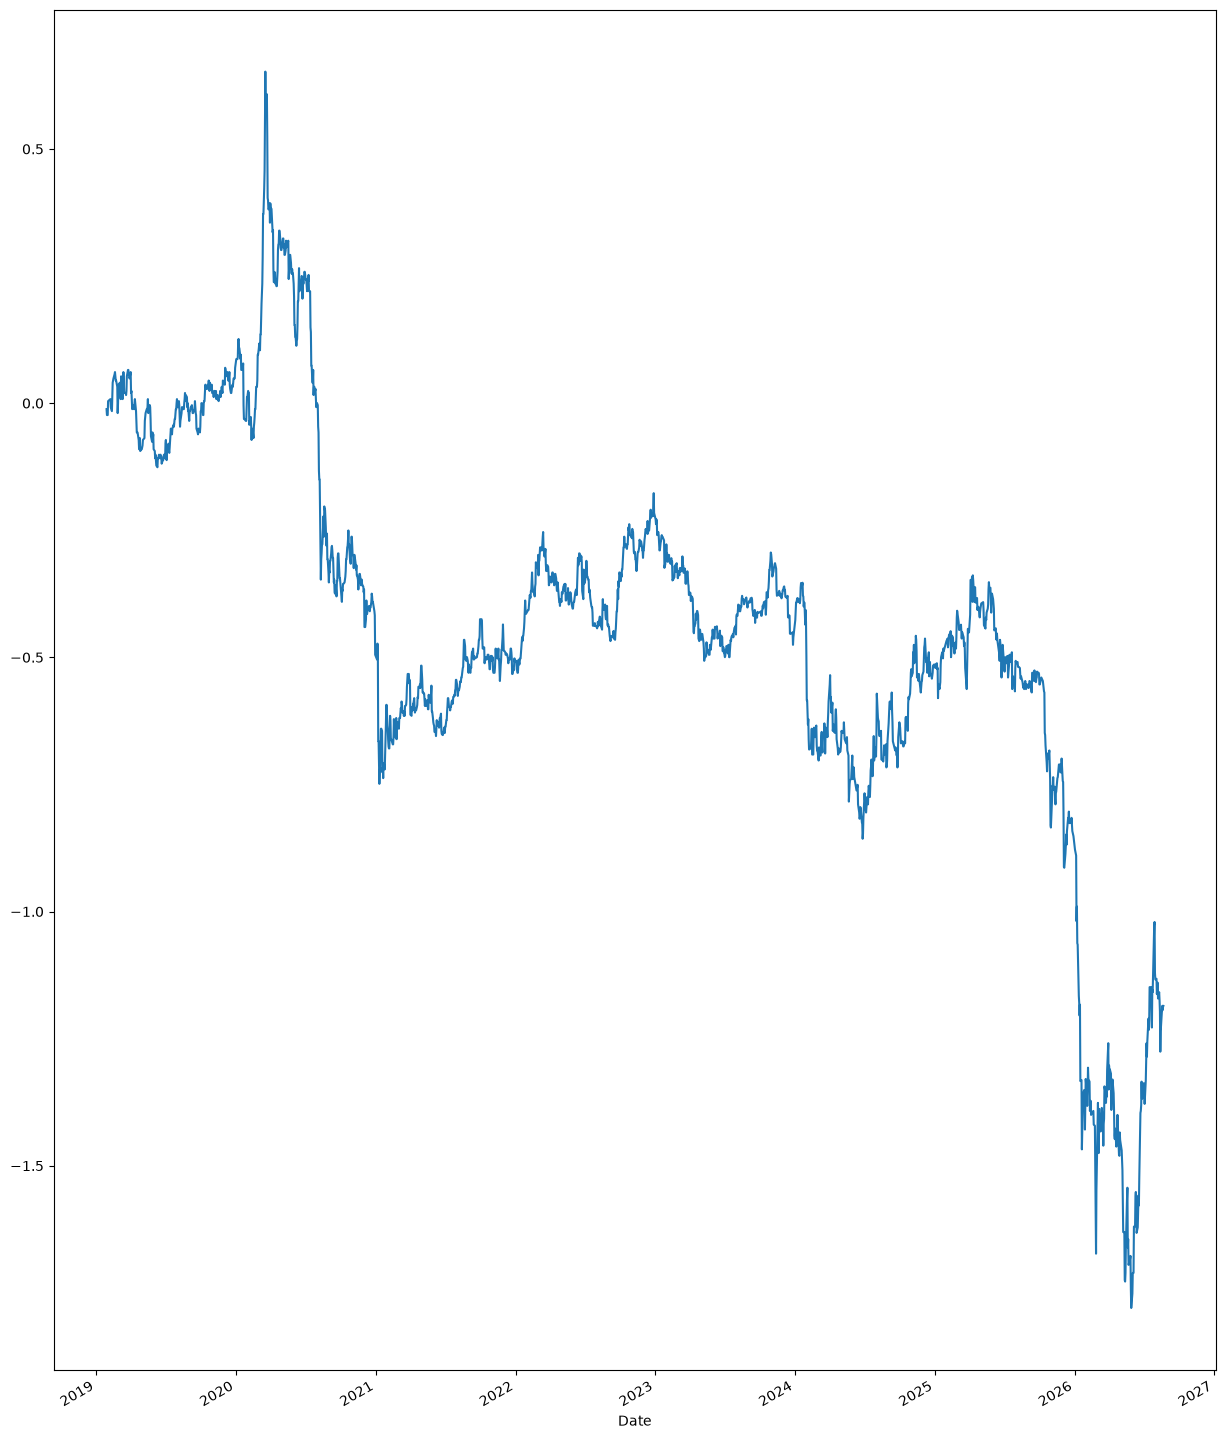

In [72]:
simulations.Logarithmic_Changes_Daily.cumsum().plot(figsize=(15,20),xlabel='Date')

In [148]:
# Running the Monte Carlo Simulation
live_days=252
ann_simulation_mean=simulations.Logarithmic_Changes_Daily.mean() *live_days #Multiply by live days because it is 'daily' and you want annual mean
ann_simulation_mean
ann_simulation_stdev=simulations.Logarithmic_Changes_Daily.std()*np.sqrt(live_days)
datas=[ann_simulation_mean,ann_simulation_stdev]
reps=500
simulator=np.random.normal(ann_simulation_mean/live_days,ann_simulation_stdev/np.sqrt(live_days),(live_days,reps)) #Generates values of normal distributions with [mean = simulation_mean, stdev = simulation_stdev]
simulator

array([[-0.00366157, -0.01639824,  0.00810585, ...,  0.01816677,
        -0.01623203,  0.04721414],
       [ 0.01234323, -0.02031453, -0.00475554, ...,  0.01608543,
         0.03467659, -0.01980247],
       [ 0.00814308,  0.00207479, -0.02774125, ...,  0.02912549,
        -0.00609081, -0.01262793],
       ...,
       [ 0.015513  ,  0.01566398, -0.01408455, ...,  0.00724103,
         0.00460951,  0.00478505],
       [-0.01582235, -0.01656728,  0.00013706, ...,  0.02061876,
        -0.00068133, -0.02916504],
       [ 0.04940908,  0.01266119,  0.00247943, ..., -0.04050026,
         0.02366543,  0.01869916]], shape=(252, 500))

In [149]:
simulations

,Price_AUD,Percent_AUD,Cumfactor,Logarithmic_Changes_Daily,Present Value,Years,Present_Value
Date,,,,,,,
2019-01-28,127.773906,-0.011719,0.988281,-0.011788,118.992276,0.000000,127.773906
2019-01-29,129.289011,-0.011583,0.988417,-0.011651,120.403251,0.002738,129.263810
2019-01-30,130.804117,0.000000,1.000000,0.000000,121.814227,0.005476,130.753128
2019-01-31,130.804117,0.000000,1.000000,0.000000,121.814227,0.008214,130.727640
2019-02-01,130.804117,0.027778,1.027778,0.027399,121.814227,0.010951,130.702158
...,...,...,...,...,...,...,...
2026-08-14,457.561892,0.041379,1.041379,0.040546,426.114632,7.542779,267.424677
2026-08-18,439.380625,0.050725,1.050725,0.049480,409.182925,7.553730,256.598363
2026-08-19,418.169146,-0.008383,0.991617,-0.008419,389.429267,7.556468,244.163252


In [150]:
wacc = 0.0738

reference_date = simulations.index.min()

simulations['Years'] = (
    simulations.index - reference_date
).days / 365.25

simulations['Present_Value'] = (
    simulations['Price_AUD'] /
    (1 + wacc) ** simulations['Years']
) #Calculates Value of Shares back to Present value

simulations

,Price_AUD,Percent_AUD,Cumfactor,Logarithmic_Changes_Daily,Present Value,Years,Present_Value
Date,,,,,,,
2019-01-28,127.773906,-0.011719,0.988281,-0.011788,118.992276,0.000000,127.773906
2019-01-29,129.289011,-0.011583,0.988417,-0.011651,120.403251,0.002738,129.263810
2019-01-30,130.804117,0.000000,1.000000,0.000000,121.814227,0.005476,130.753128
2019-01-31,130.804117,0.000000,1.000000,0.000000,121.814227,0.008214,130.727640
2019-02-01,130.804117,0.027778,1.027778,0.027399,121.814227,0.010951,130.702158
...,...,...,...,...,...,...,...
2026-08-14,457.561892,0.041379,1.041379,0.040546,426.114632,7.542779,267.424677
2026-08-18,439.380625,0.050725,1.050725,0.049480,409.182925,7.553730,256.598363
2026-08-19,418.169146,-0.008383,0.991617,-0.008419,389.429267,7.556468,244.163252


In [151]:
starting_price = simulations['Present_Value'].iloc[-1]

# Generate Monte Carlo price paths
p_estimate = starting_price * np.cumprod(1 + simulator, axis=0)

# Convert to DataFrame
df2 = pd.DataFrame(p_estimate)

In [152]:
for i in simulations['Present_Value']:
    p_estimate=i * np.cumprod(1+simulator,axis=0)
    df=pd.DataFrame(p_estimate)


In [184]:
simulations['Present_Value']
simulations.to_csv('simulations.csv')

Text(0.5, 1.0, 'Hyundai Monte Carlo Price Simulation')

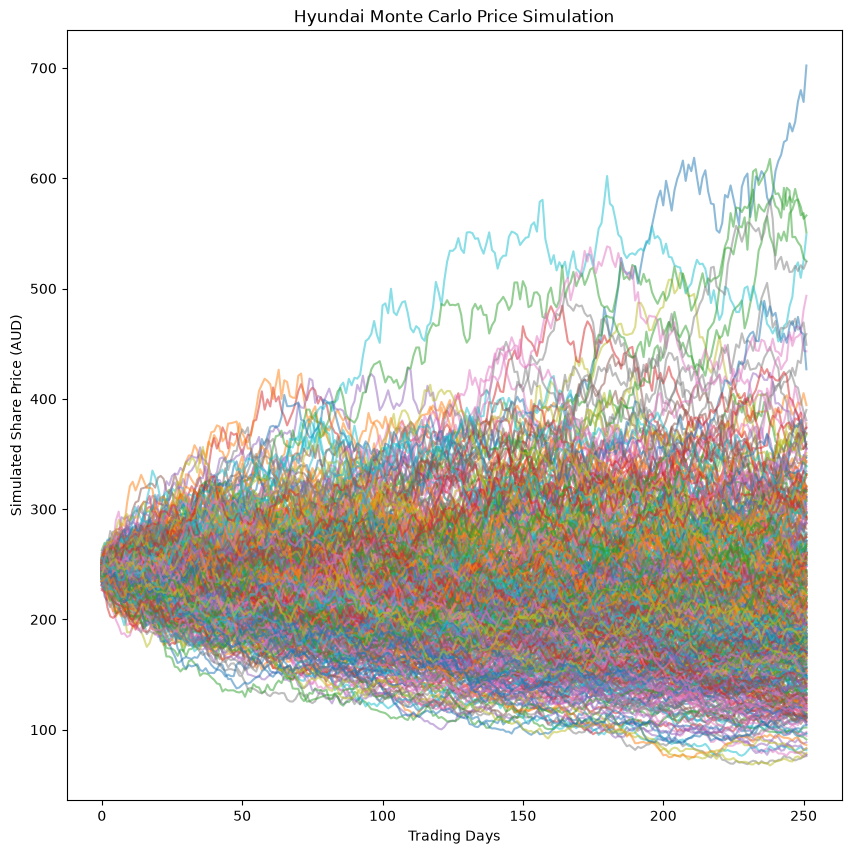

In [185]:
plt.figure(figsize=(10,10))
plt.plot(df2[:],alpha=0.5)
plt.xlabel('Trading Days')
plt.ylabel('Simulated Share Price (AUD)')
plt.title('Hyundai Monte Carlo Price Simulation')

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,243.761779,240.645656,246.640768,247.969666,241.565529,241.014079,242.008430,239.273336,251.049080,247.897059,...,240.973470,234.499708,238.857809,250.578522,247.744836,246.766042,245.854228,249.102249,240.686319,256.208908
1,246.770586,235.757054,245.467858,241.191289,248.805269,235.860386,235.172532,237.879335,252.839453,244.581845,...,241.453693,237.371425,238.954591,259.314496,242.488056,249.292754,255.181230,253.109167,249.032501,251.135340
2,248.780059,236.246200,238.658273,245.275969,253.048203,233.439959,242.475154,240.647691,253.192807,251.930140,...,240.905784,239.802768,246.241872,259.766289,244.628056,246.648998,262.141557,260.481096,247.515691,247.964019
3,246.925619,242.923962,234.728161,241.001891,251.222718,240.841102,246.649694,230.938583,257.754142,243.994742,...,245.752615,232.888874,254.564956,263.232852,252.924120,255.765534,252.462201,262.684098,251.099572,245.976954
4,253.433075,242.771609,234.913394,248.842663,250.911169,250.031451,232.775662,222.127455,256.124366,241.093915,...,235.155802,237.563361,254.184511,266.266982,247.830792,249.834021,249.516784,250.800992,253.486024,247.938299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,651.042800,251.787030,262.453643,193.473035,164.243286,252.026889,185.650803,316.678032,242.115294,248.828420,...,177.137979,205.792089,259.195087,298.748962,149.090102,131.508114,118.214725,234.852285,188.846841,295.927676
248,669.538796,257.977921,260.274554,185.947499,169.299304,249.774142,181.273041,311.125701,245.389720,244.698459,...,175.018805,213.934386,259.217275,303.663429,151.271417,133.346604,116.708150,234.764706,187.911805,299.013153
249,679.925354,262.018881,256.608705,186.262500,163.365520,250.014046,178.127957,313.177683,248.380643,240.805750,...,178.448953,206.133819,268.782550,300.427471,151.390449,132.982670,118.936057,236.464644,188.777987,300.443944
250,669.167335,257.677940,256.643876,186.209185,161.736668,259.909336,179.126219,319.621718,249.776971,241.806533,...,184.098530,207.029204,263.454592,293.531463,148.330835,132.153976,118.067691,241.340252,188.649367,291.681485


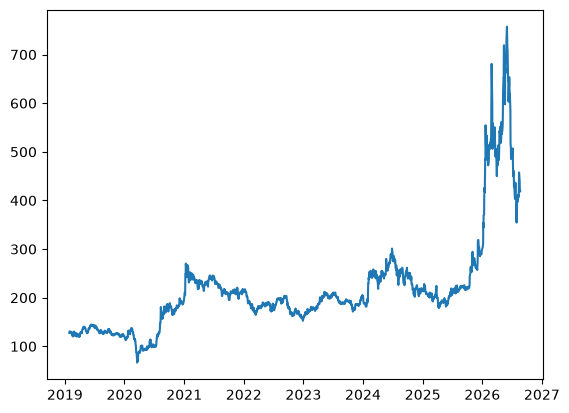

In [186]:
plt.plot(simulations['Price_AUD'])
df2